# Loan Approval Prediction System

This project uses machine learning to predict whether a loan application should be approved based on applicant financial and demographic information.

The objective is to automate preliminary credit risk assessment and improve decision-making efficiency in loan processing systems.

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

## Libraries Used

- Pandas and NumPy for data manipulation
- Matplotlib for visualization
- Scikit-learn for preprocessing, training, and evaluation

## Dataset Description

The dataset contains simulated applicant's information used to determine loan approval eligibility.

### Features:
 - User_age
 - Income
 - Employment_status
 - Credit_score
 - Loan_amount
 - Loan_term
 - Existing_debt
 - Loan_to_income_ratio
 - Payment_history
 - Num_of_defaults
 - Savings_balance

### Target Variable:
- Loan_Status
    - Y = Approved
    - N = Rejected

In [149]:
data = pd.read_csv("loan_data.csv")
data

,user_age,income,employment_status,credit_score,loan_amount,loan_term,existing_debt,loan_to_income_ratio,payment_history,num_of_defaults,savings_balance
0,59,532831,Self-employed,403,152023,21,201146,0.377504,Good,1,159849.3
1,49,277541,Employed,660,658667,14,61021,0.219863,Good,1,83262.3
2,35,5211,Unemployed,315,82388,5,182854,35.090002,Bad,6,1563.3
3,28,510329,Self-employed,631,879200,20,232979,0.456527,Bad,6,153098.7
4,41,28244,Unemployed,408,823860,19,25642,0.907874,Bad,9,8473.2
...,...,...,...,...,...,...,...,...,...,...,...
2995,44,21488,Unemployed,439,733576,22,255935,11.910601,Average,3,6446.4
2996,39,713029,Self-employed,519,12068,10,377140,0.528927,Bad,8,213908.7
2997,57,48394,Employed,797,580748,8,226760,4.685705,Bad,9,14518.2
2998,59,181978,Self-employed,741,889198,16,62321,0.342464,Average,4,54593.4


## Data Loading

The dataset was loaded into a Pandas DataFrame for preprocessing and analysis.

In [150]:
data = data.dropna()
data = data.drop_duplicates()

## Missing Value And Duplicates Analysis

This being a simulated data doesn't have missing values but real world datas do especially in:
- Income
- Credit History
- Employment History
- Existing Debt

Handling missing values is important because many machine learning algorithms cannot process null data directly, so if there where any missing values, i would have filled up the values with the mean of the column.

In [151]:
emp_s = data["employment_status"]
emps = [2/2 if i == "Employed" else 1/2 if i == "Unemployed" else 0/2 for i in emp_s]
emps = pd.Series(emps)

In [152]:
pay_h = data["payment_history"]
payh = [2/2 if i == "Good" else 1/2 if i == "Average" else 0/2 for i in pay_h]
payh = pd.Series(payh)

In [153]:
num_d = 1 - (data["num_of_defaults"]/10)

In [154]:
cred_s = data["credit_score"]/850

In [155]:
inc = (data["income"]/data["income"].max())

In [156]:
affordability_ratio = (data["income"] / data["loan_amount"])
z = (np.log1p(affordability_ratio) - np.log1p(affordability_ratio).mean()) / np.log1p(affordability_ratio).std()
affordability_score = 1 / (1 + np.exp(-z))

In [157]:
risk_ratio = (data["existing_debt"] + data["loan_amount"]) / (data["income"] + data["savings_balance"])
risk_ratio = risk_ratio.replace([np.inf, -np.inf],np.nan)
risk_ratio = risk_ratio.fillna(risk_ratio.median())

risk_log = np.log1p(risk_ratio)

risk_final = (risk_log - risk_log.mean()) / risk_log.std()
z = (risk_final - risk_final.min()) / (risk_final.max() - risk_final.min())
# z = (np.log1p(risk_final) - np.log1p(risk_final).mean()) / np.log1p(risk_final).std()
risk_scale = 1 / (1 + np.exp(-z))

In [158]:
loan_approval_rating = ((0.3*cred_s)+(0.2*risk_scale)+(0.1*emps)+(0.1*payh)+(0.1*num_d)+(0.1*inc)+(0.1*affordability_score))

# Feature Engineering

New features were created from existing variables to improve the model’s ability to identify meaningful financial patterns.

### Features Created:
 - Income
 - affordability_score
 - risk_scale
 - Employment_status
 - Credit_score
 - Existing_debt
 - risk_ratio
 - affordability_ratio
 - loan_approval_rating

<function matplotlib.pyplot.show(close=None, block=None)>

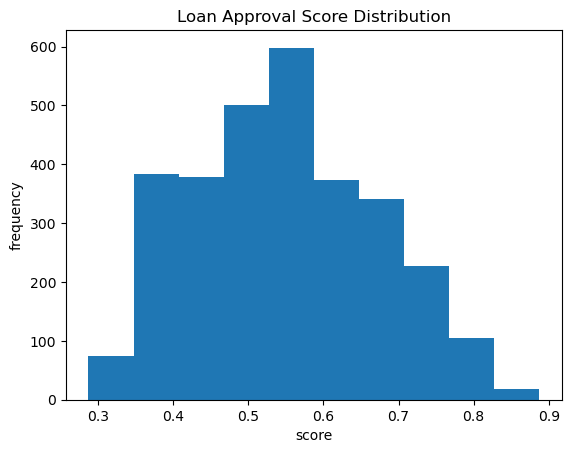

In [159]:
plt.hist(loan_approval_rating)
plt.title("Loan Approval Score Distribution")
plt.xlabel("score")
plt.ylabel("frequency")
plt.show

# Visualization Overview: Loan Approval Score Distribution

## Key Components of the Graph
 - X-Axis (score): Represents the loan approval ratings, ranging approximately from 0.3 to 0.9.

 - Y-Axis (frequency): Represents the count of occurrences (how many loans fall into each score bracket), ranging from 0 to 600.

 - The Bins: Each blue bar represents a "bin" or range of scores. The height of the bar tells you how many data points exist within that specific score range.

## Data Observation

 - Peak Frequency: The highest density of scores (the "mode") occurs between 0.5 and 0.6, where the frequency reaches its peak at 600.

 - Distribution Shape: The data appears roughly normally distributed (bell-shaped) but with a slight "right skew" or tail, meaning there are fewer loans with very high scores (above 0.8) compared to the mid-range.

 - Concentration: Most loan approval ratings are concentrated between 0.4 and 0.7.

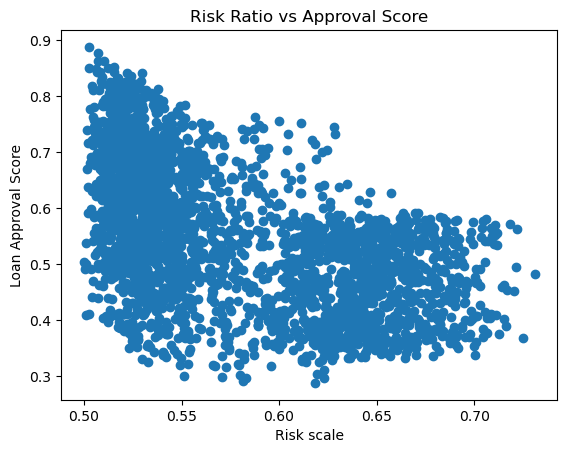

In [160]:
plt.scatter(risk_scale, loan_approval_rating)
plt.xlabel("Risk scale")
plt.ylabel("Loan Approval Score")
plt.title("Risk Ratio vs Approval Score")
plt.show()

# Visualization Overview: Risk Ratio vs. Approval Score

## Key Components of the Graph
 - X-Axis (Risk scale): Represents the risk level associated with a loan, ranging from 0.50 to roughly 0.75.

 - Y-Axis (Loan Approval Score): Represents the final approval rating, ranging from 0.3 to 0.9.

 - Data Points: Each individual dot represents a single loan application, showing its specific risk level compared to its approval score.

## Data Observations
 - Negative Correlation: There is a visible downward trend—as the Risk scale increases (moves to the right), the Loan Approval Score generally decreases (moves down). This indicates that higher risk typically leads to lower approval ratings.

 - Density at Low Risk: The highest approval scores (above 0.8) are concentrated exclusively at the lower end of the risk scale (around 0.50).

 - Variance: As risk increases, the "spread" of approval scores tightens. There is a wide variety of outcomes at low risk, but high-risk loans (0.70+) rarely achieve a score above 0.6.

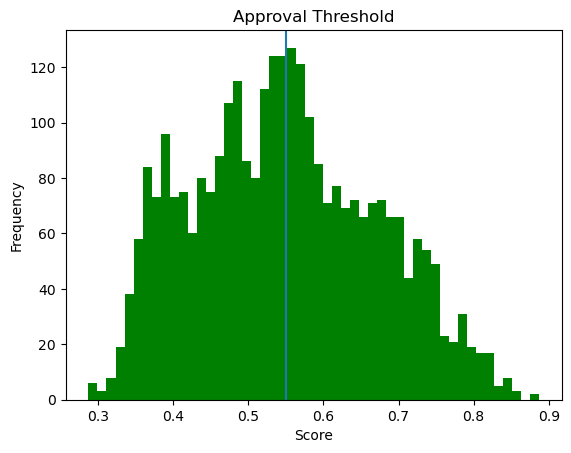

In [161]:
threshold = 0.55

plt.hist(loan_approval_rating, bins=50, color = "green")
plt.axvline(threshold)
plt.title("Approval Threshold")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# Visualization Overview: Approval Threshold

## Key Components of the Graph

 - X-Axis (Score): Represents the loan scores, ranging from approximately 0.3 to 0.9.

 - Y-Axis (Frequency): Represents the number of applicants falling into each score bracket, peaking at over 120.

 - Vertical Blue Line: This represents the threshold value of 0.55. It acts as a visual separator between "approved" and "rejected" categories.

 - Green Bins: The data is broken into 50 bins (as specified by bins=50), providing a more granular look at the score distribution compared to previous charts.

## Data Observations
 - Decision Impact: The blue line shows that a significant portion of the population falls just above and just below the 0.55 threshold.

 - High-Resolution Distribution: By increasing the bins to 50, we can see more "noise" or fluctuations in the score frequency, revealing that the most common scores are clustered very tightly around the 0.55 mark.

 - Skewness: The distribution remains roughly centered but shows a tapering off as scores approach the high end (0.8+).

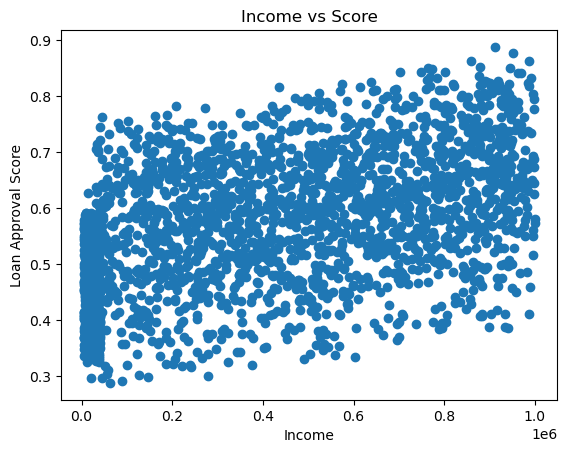

In [162]:
plt.scatter(data["income"], loan_approval_rating)
plt.xlabel("Income")
plt.ylabel("Loan Approval Score")
plt.title("Income vs Score")
plt.show()

# Visualization Overview: Income vs. Score

## Key Components of the GraphX-Axis (Income): 
 - Represents the applicant's income, shown in scientific notation (up to $1.0 \times 10^6$ or 1,000,000).
   
 - Y-Axis (Loan Approval Score): Represents the approval rating on a scale from 0.3 to 0.9.
   
 - Data Points: Each dot represents an individual data entry mapping a specific income level to its corresponding approval score.

   
## Data ObservationsPositive Correlation: 

 - There is a general upward trend visible in the data. As Income increases, the Loan Approval Score tends to rise, suggesting that higher income is a favorable factor for a better score.



 - High Density at Lower Income: There is a significant cluster of data points at the lower end of the income scale (near 0.0 on the X-axis), indicating that a large portion of the dataset consists of applicants with lower income levels.

   
 - Increasing "Floor" for Scores: While there is still variance, applicants with the highest incomes ($800,000$ to $1,000,000$) rarely fall below a score of 0.4, whereas lower-income applicants frequently see scores as low as 0.3.

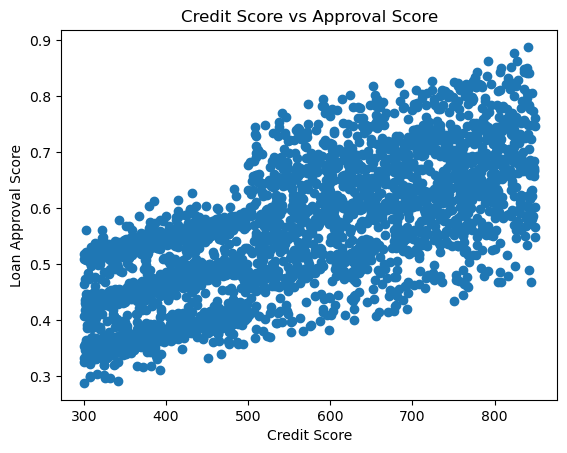

In [163]:
plt.scatter(data["credit_score"], loan_approval_rating)
plt.xlabel("Credit Score")
plt.ylabel("Loan Approval Score")
plt.title("Credit Score vs Approval Score")
plt.show()

# Visualization Overview: Credit Score vs Approval Score

## Key Components of the Graph
 - X-Axis (Credit Score): Represents traditional credit scores, ranging from 300 to 850.

 - Y-Axis (Loan Approval Score): Represents the internal approval rating, ranging from approximately 0.3 to 0.9.

 - Data Points: Each dot represents a single loan applicant's position relative to both metrics.

## Data Observations
 - Strong Positive Correlation: There is a clear upward trend; as the Credit Score increases, the Loan Approval Score also increases. This suggests the model heavily values traditional creditworthiness.

 - Distinct Tiering: Around the 500 credit score mark, there is a visible "jump" or upward shift in the density of higher approval scores.

 - Predictability: Unlike the income plot, this graph shows a tighter cluster of data points. This indicates that credit score is a very consistent predictor for the loan approval rating, with fewer extreme outliers at high credit tiers.

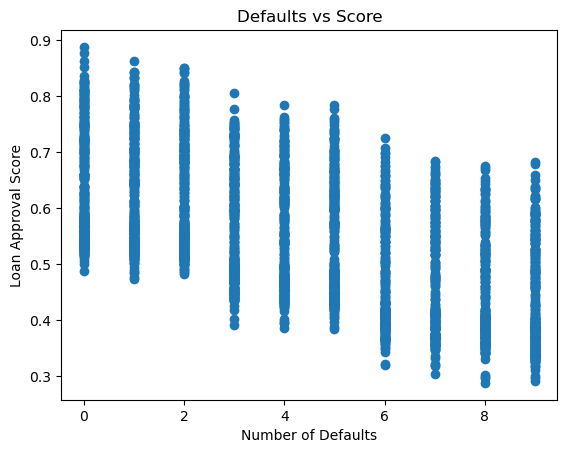

In [164]:
plt.scatter(data["num_of_defaults"], loan_approval_rating)
plt.xlabel("Number of Defaults")
plt.ylabel("Loan Approval Score")
plt.title("Defaults vs Score")
plt.show()

# Visualization Overview: Defaults vs. Score

## Key Components of the Graph

 - X-Axis (Number of Defaults): Represents the count of prior defaults, ranging from 0 to 9.

 - Y-Axis (Loan Approval Score): Represents the approval rating, ranging from approximately 0.3 to 0.9.

 - Vertical Clusters: Each column of dots represents the full range of approval scores for applicants with that specific number of defaults.

## Data Observations

 - Inverse Relationship: There is a clear negative trend; as the Number of Defaults increases, the maximum possible Loan Approval Score decreases.

 - Maximum Score Caps: Applicants with 0 defaults can reach scores near 0.9. However, once an applicant reaches 9 defaults, the highest score they can achieve is significantly lower, capped below 0.7.

 - Penalty Steps: There is a noticeable drop in the "score ceiling" at specific intervals, particularly after 2 defaults and again after 5 defaults, indicating the model heavily penalizes repeat offenders.

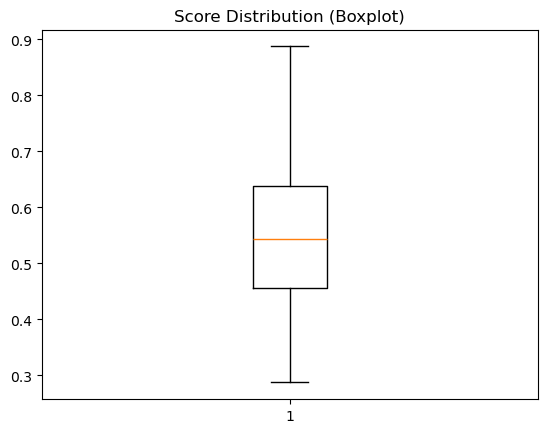

In [165]:
plt.boxplot(loan_approval_rating)
plt.title("Score Distribution (Boxplot)")
plt.show()

# Visualization Overview: Score Distribution (Boxplot)

## Key Components of the Graph

 - The Orange Line (Median): This represents the middle value of the dataset, located at approximately 0.55.

 - The Box (Interquartile Range - IQR): The box contains the middle 50% of the data.

 - The bottom edge (Q1) is around 0.45.

 - The top edge (Q3) is around 0.63.

 - The Whiskers: The vertical lines extending from the box show the overall range of the data (minimum and maximum values), excluding outliers.

 - Y-Axis: Represents the Loan Approval Score on a scale from 0.3 to 0.9.

## Data Observations

 - Symmetry: The median line is almost perfectly centered within the box, indicating that the core distribution of scores is quite balanced.

 - Range: We can see the absolute minimum score is just below 0.3, and the absolute maximum reaches nearly 0.9.

 - Lack of Outliers: Usually, outliers appear as individual dots beyond the whiskers. In Screenshot 2026-05-14 022609.png, there are no visible dots, suggesting the loan scores fall within a statistically expected range without extreme anomalies.

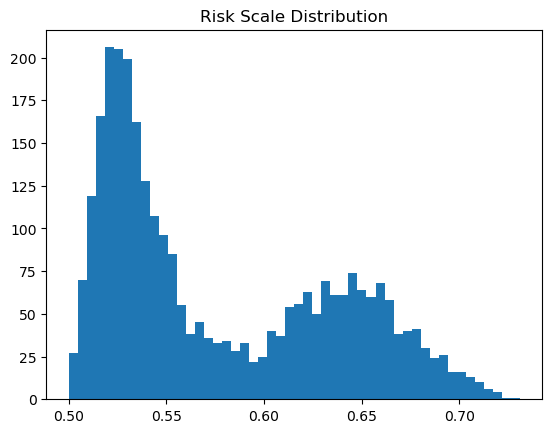

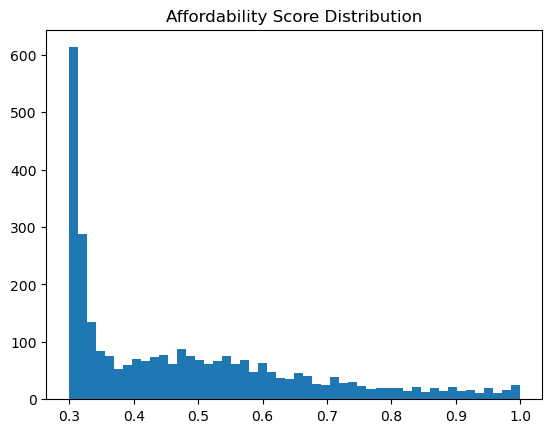

In [166]:
plt.hist(risk_scale, bins=50)
plt.title("Risk Scale Distribution")
plt.show()

plt.hist(affordability_score, bins=50)
plt.title("Affordability Score Distribution")
plt.show()

# Visualization Overview: Risk Scale Distribution

 - Bimodal Distribution: Unlike the other charts, this shows two distinct "humps" or peaks. The primary peak is at a lower risk level (around 0.52), and a secondary, smaller peak occurs around 0.65. This suggests two common "types" of risk profiles in the data.

 - X-Axis (Risk Scale): Ranges from 0.50 to roughly 0.75.

 - Granularity: By using bins=50, the plot reveals a sharp drop-off in frequency between the two peaks (around the 0.58 mark).

# Visualization Overview: Affordability Score Distribution

 - Right-Skewed Distribution: The data is heavily weighted toward the left. A massive number of applicants (over 600) have a very low affordability score (around 0.3).

 - X-Axis (Affordability Score): Ranges from 0.3 to 1.0.

 - The "Long Tail": As the score increases toward 1.0, the frequency drops significantly. This indicates that while many people can barely afford the loans, very few applicants fall into the "high affordability" bracket.

In [167]:
income = data["income"]
credit_score = data["credit_score"]
loan_amount = data["loan_amount"]
existing_debt = data["existing_debt"]
credit_score = data["credit_score"]

# Model Training and Evaluation

## Feature Selection and Data Splitting

 - Feature Matrix ($X$): The model utilizes five key predictors: income, credit_score, num_of_defaults, loan_amount, and existing_debt.

 - Target Variable ($y$): The model aims to predict the loan_approval_rating.

 - Train-Test Split: The dataset was divided using a 80/20 split (test_size=0.2), with a random_state=42 to ensure the results are reproducible.

In [168]:
X = data[["income", "credit_score", "num_of_defaults", "loan_amount", "existing_debt"]]
y = loan_approval_rating

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [169]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [170]:
y_pred = model.predict(X_test)

# Model Implementation

 - Algorithm: A Linear Regression model was selected for this task.

 - Training: The model was "fitted" using the training data (X_train, y_train), allowing it to learn the mathematical relationships between the applicant's financial features and their final score.

In [171]:
mse = mean_squared_error(y_test, y_pred)
print(mse)

0.0017313925190692166


In [172]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.890436783063004


# Performance Metrics
After making predictions on the unseen test set (y_pred), the model's accuracy was measured using two standard metrics:

 - Mean Squared Error (MSE): The model achieved an MSE of approximately 0.0017. This very low value indicates that the average squared difference between the predicted ratings and the actual ratings is minimal, suggesting high precision.

 - R-squared ($R^2$) Score: The model achieved an $R^2$ score of approximately 0.8904. This means that roughly 89% of the variance in loan approval ratings can be explained by the input features, indicating a strong predictive performance.

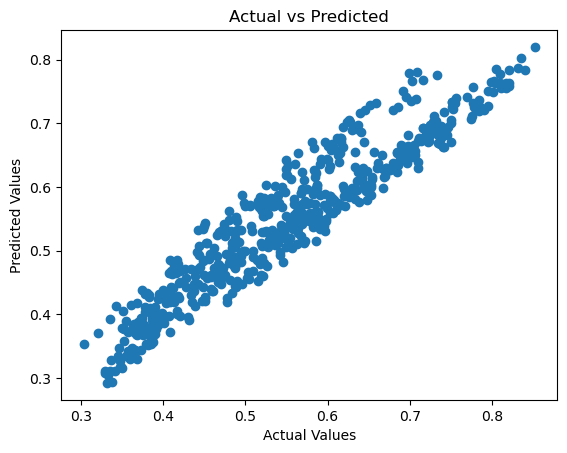

In [173]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# Visualization Overview: Actual vs. Predicted Values

## Key Components of the GraphX-Axis (Actual Values): 

 - Represents the ground-truth loan approval scores from the test set.

 - Y-Axis (Predicted Values): Represents the scores the Linear Regression model calculated based on the input features.

 - Diagonal Alignment: In a perfect model, all dots would form a straight $45^{\circ}$ diagonal line ($y = x$).

## Data ObservationsStrong Linear Relationship: 

 - The data points are tightly clustered along a diagonal path, which confirms the high $R^{2}$ score (0.8904) observed in the previous step.

 - Model Precision: The lack of significant outliers or wide "blobs" indicates that the model is consistently accurate across the entire range of scores, from low (0.3) to high (0.8+).

 - Minimal Variance: The vertical spread at any given point on the X-axis is very small, which visually validates the low Mean Squared Error (0.0017).